# Lesson 4 - Funnel & Revenue Analysis (pandas + matplotlib)

**Business question:** Lesson 3's SQL queries already answered "where does the
funnel leak, which sources/reps convert, does speed-to-lead matter" - but a
sales manager doesn't read SQL output, they look at a chart. This notebook
rebuilds the same 5 KPIs in pandas (so the numbers can be checked against
Lesson 3's SQL results - if both pipelines agree, we can trust the pipeline,
not just one query) and turns each one into a chart, saved as a PNG. Those
PNGs get reused later in the README, the Excel workbook, and the Power BI
report - this notebook is the one place the "analysis" actually happens; every
later output just repackages what we compute here.

One extra thing pandas is good at that a single SQL query isn't: a monthly
trend over the full 18-month history, at the end.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# every chart this notebook makes gets saved here - the README, Excel
# workbook, and Power BI report all pull PNGs from this same folder later
ASSETS_DIR = Path("../assets")
ASSETS_DIR.mkdir(exist_ok=True)

# a small, FIXED color palette reused across every chart instead of letting
# each chart pick its own colors. BLUE is the one hue used everywhere a chart
# is just comparing magnitudes; ORANGE is reserved for calling out a single
# standout value (the top source, the top rep) so it always means the same
# thing when it shows up.
BLUE = "#2a78d6"
ORANGE = "#eb6834"
GRID = "#e1e0d9"
INK = "#0b0b0b"
MUTED = "#52514e"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "figure.dpi": 110,
})


## Load the cleaned data

Same file Lesson 3 loaded into MySQL: `data/leads_cleaned.csv`. This time
`created_at`/`closed_at` get parsed straight into real datetime columns on
load (`parse_dates=`), because the monthly trend chart at the end needs to
group by month - something you can't do on a plain text column.


In [3]:
df = pd.read_csv("../data/leads_cleaned.csv", parse_dates=["created_at", "closed_at"])
print(f"{len(df):,} leads loaded, {df['created_at'].min().date()} to {df['created_at'].max().date()}")
df.head(3)


7,000 leads loaded, 2025-01-01 to 2026-06-29


,lead_id,created_at,source,product,region,rep,response_time_hours,stage_reached,status,lost_reason,deal_value,closed_at
0,LD-300000,2025-11-14 14:30:00,Webinar,Coding for Kids,International,Rep_15,0.57,Closed,Won,NaN,574.72,2025-12-15 09:41:11.226466
1,LD-300001,2026-06-12 16:52:00,Organic Search,Language Learning,North Region,Rep_01,2.72,Contacted,Open,NaN,NaN,NaT
2,LD-300002,2026-01-21 15:02:00,Organic Search,Coding for Kids,South Region,Rep_12,1.63,Demo Completed,Lost,Went With Competitor,673.32,2026-02-25 19:23:42.793161


## KPI 1 - Funnel by stage

In `02_kpi_queries.sql` this was a non-equi `JOIN` against a `stage_order`
lookup table: a lead that reached stage 5 also counts toward stages 1-4,
because it had to pass through them to get there. pandas does the same
cumulative idea with a boolean mask instead of a `JOIN` - "how many leads have
a stage number >= this stage's number."


In [4]:
STAGE_ORDER = {
    "Lead": 1, "Contacted": 2, "Demo Scheduled": 3, "Demo Completed": 4,
    "Proposal Sent": 5, "Negotiation": 6, "Closed": 7,
}
df["stage_num"] = df["stage_reached"].map(STAGE_ORDER)

funnel = pd.Series(
    {stage: (df["stage_num"] >= num).sum() for stage, num in STAGE_ORDER.items()}
)
funnel_pct = (funnel / len(df) * 100).round(1)
pd.DataFrame({"leads_reaching_or_beyond": funnel, "pct_of_total": funnel_pct})


,leads_reaching_or_beyond,pct_of_total
Lead,7000,100.0
Contacted,5783,82.6
Demo Scheduled,2693,38.5
Demo Completed,2448,35.0
Proposal Sent,1942,27.7
Negotiation,1537,22.0
Closed,935,13.4


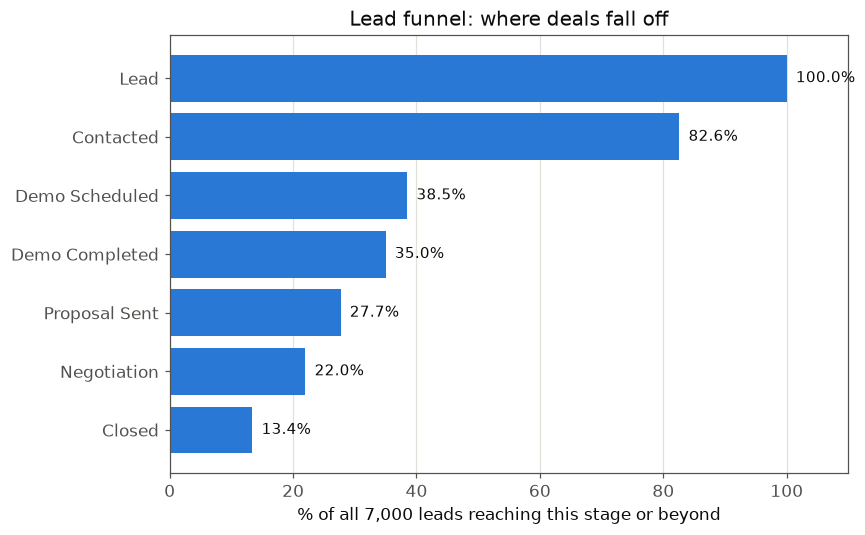

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
stages = list(STAGE_ORDER.keys())
values = funnel_pct.values

ax.barh(stages, values, color=BLUE)
ax.invert_yaxis()  # Lead at top, Closed at bottom - reads top-to-bottom like a real funnel
for i, v in enumerate(values):
    ax.text(v + 1.5, i, f"{v}%", va="center", fontsize=10)

ax.set_xlim(0, 110)
ax.set_xlabel("% of all 7,000 leads reaching this stage or beyond")
ax.set_title("Lead funnel: where deals fall off")
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(ASSETS_DIR / "01_funnel_by_stage.png", dpi=150)
plt.show()


## KPI 2 - Win rate by lead source

Same `GROUP BY source` logic as the SQL version, expressed as a pandas
`groupby`. The top source gets the orange highlight - the one color in this
notebook that always means "this is the standout value in this chart."


In [6]:
win_by_source = (
    df.groupby("source")["status"]
    .apply(lambda s: (s == "Won").mean() * 100)
    .round(1)
    .sort_values(ascending=False)
)
win_by_source


source
Referral           33.8
Webinar            26.1
Partner Channel    16.9
Organic Search     12.4
Paid Search         6.6
Social Media        3.3
Cold Outreach       0.0
Name: status, dtype: float64

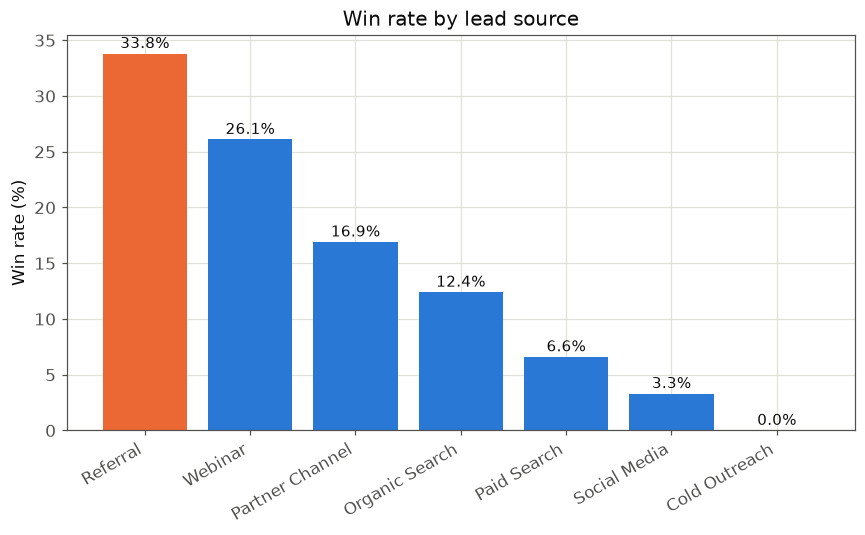

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [ORANGE if i == 0 else BLUE for i in range(len(win_by_source))]

ax.bar(win_by_source.index, win_by_source.values, color=colors)
for i, v in enumerate(win_by_source.values):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=10)

ax.set_ylabel("Win rate (%)")
ax.set_title("Win rate by lead source")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig(ASSETS_DIR / "02_win_rate_by_source.png", dpi=150)
plt.show()


## KPI 3 - Speed-to-lead effect

Same four response-time buckets as the SQL `CASE WHEN`, rebuilt as a small
Python function passed to `.apply()`. The fastest bucket is highlighted -
it's the one a rep or manager can actually act on ("call back within the
hour"), unlike source or region which aren't really controllable day to day.


In [8]:
def response_bucket(hours):
    if hours <= 1:
        return "1. Under 1 hour"
    if hours <= 24:
        return "2. 1-24 hours"
    if hours <= 72:
        return "3. 1-3 days"
    return "4. Over 3 days"

df["response_bucket"] = df["response_time_hours"].apply(response_bucket)
win_by_speed = (
    df.groupby("response_bucket")["status"]
    .apply(lambda s: (s == "Won").mean() * 100)
    .round(1)
)
win_by_speed


response_bucket
1. Under 1 hour    22.8
2. 1-24 hours      12.3
3. 1-3 days         6.1
4. Over 3 days      0.0
Name: status, dtype: float64

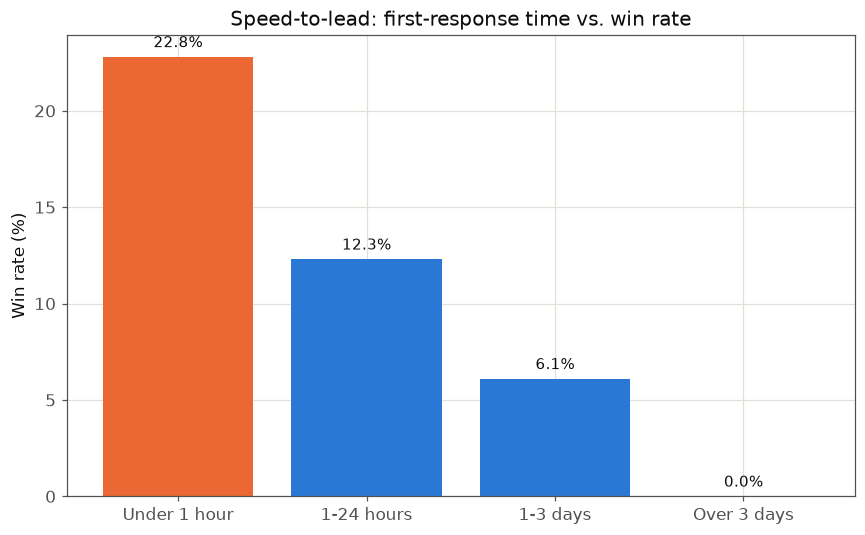

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = [b.split(". ")[1] for b in win_by_speed.index]
colors = [ORANGE if i == 0 else BLUE for i in range(len(win_by_speed))]

ax.bar(labels, win_by_speed.values, color=colors)
for i, v in enumerate(win_by_speed.values):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=10)

ax.set_ylabel("Win rate (%)")
ax.set_title("Speed-to-lead: first-response time vs. win rate")
fig.tight_layout()
fig.savefig(ASSETS_DIR / "03_win_rate_by_response_time.png", dpi=150)
plt.show()


## KPI 4 - Lost pipeline value by reason

Only rows where `status == "Lost"` have a `lost_reason` and a `deal_value` (a
lead that never got far enough to have a quoted price has neither). This is
money that was in the pipeline and didn't close - sorted descending, so the
biggest lever for the sales org shows up first.


In [10]:
lost = df[df["status"] == "Lost"]
lost_by_reason = (
    lost.groupby("lost_reason")["deal_value"]
    .agg(lost_deals="count", total_lost_value="sum", avg_lost_value="mean")
    .round(2)
    .sort_values("total_lost_value", ascending=False)
)
lost_by_reason


,lost_deals,total_lost_value,avg_lost_value
lost_reason,,,
Price Objection,475,363258.99,764.76
No Response / Ghosted,329,244275.96,742.48
Bad Timing,309,228129.69,738.28
Went With Competitor,259,188559.50,728.03
Budget Not Approved,141,103722.29,735.62


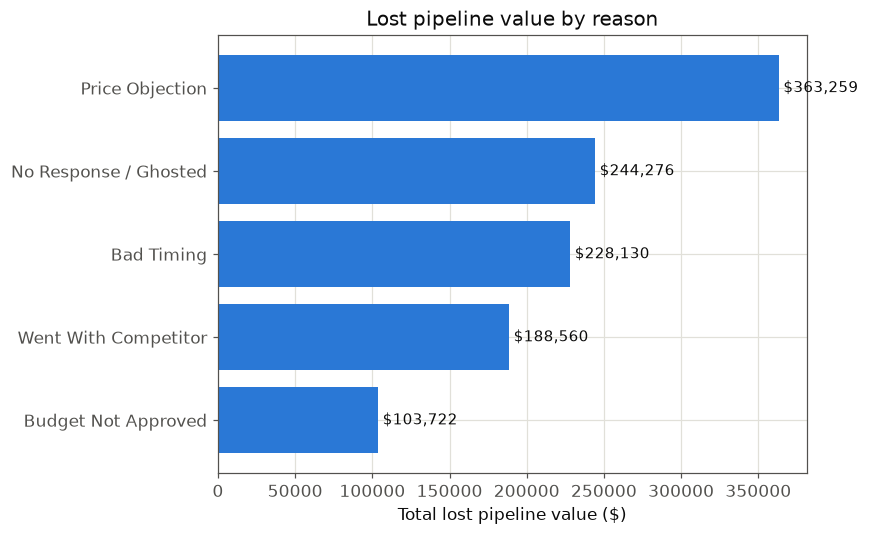

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(lost_by_reason.index, lost_by_reason["total_lost_value"], color=BLUE)
ax.invert_yaxis()
for i, v in enumerate(lost_by_reason["total_lost_value"]):
    ax.text(v + 3000, i, f"${v:,.0f}", va="center", fontsize=10)

ax.set_xlabel("Total lost pipeline value ($)")
ax.set_title("Lost pipeline value by reason")
fig.tight_layout()
fig.savefig(ASSETS_DIR / "04_lost_value_by_reason.png", dpi=150)
plt.show()


## KPI 5 - Rep leaderboard

Same conditional-sum idea as the SQL `SUM(CASE WHEN status='Won' THEN
deal_value ELSE 0 END)`, done in pandas with `.where()`: build a `won_value`
column that's the deal value when the lead was won and 0 otherwise, then sum
it per rep with `groupby`.


In [12]:
df["won_flag"] = df["status"] == "Won"
df["won_value"] = df["deal_value"].where(df["won_flag"], 0)

rep_leaderboard = df.groupby("rep").agg(
    total_leads=("lead_id", "count"),
    won=("won_flag", "sum"),
    total_revenue=("won_value", "sum"),
)
rep_leaderboard["win_rate_pct"] = (rep_leaderboard["won"] / rep_leaderboard["total_leads"] * 100).round(1)
rep_leaderboard = rep_leaderboard.sort_values("total_revenue", ascending=False)
rep_leaderboard.head(5)


,total_leads,won,total_revenue,win_rate_pct
rep,,,,
Rep_08,473,138,103895.15,29.2
Rep_11,572,123,88006.56,21.5
Rep_12,622,121,86949.75,19.5
Rep_02,650,109,84315.70,16.8
Rep_01,546,82,63751.89,15.0


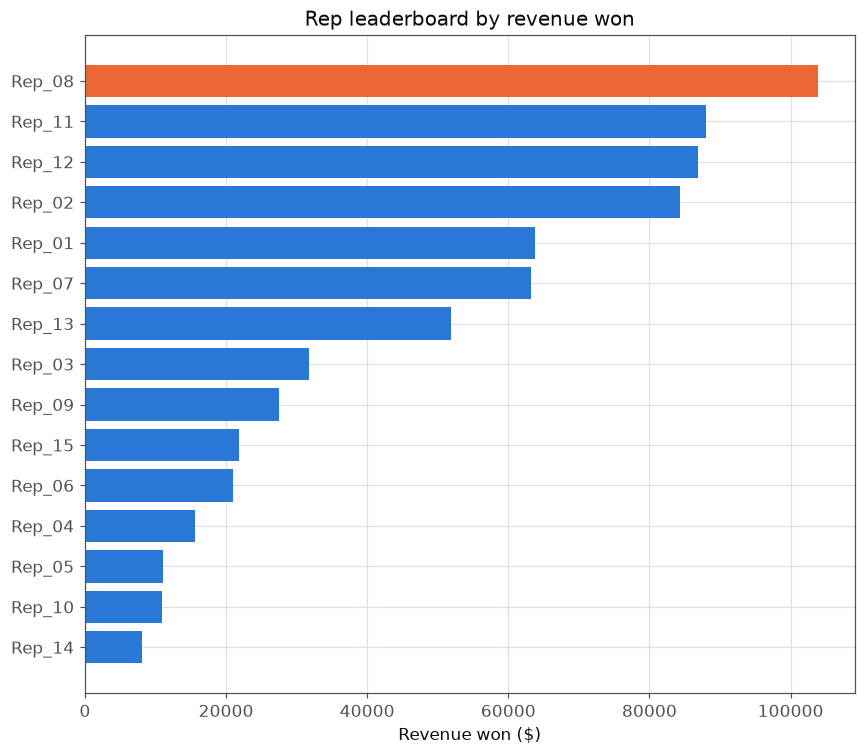

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = [ORANGE] + [BLUE] * (len(rep_leaderboard) - 1)

ax.barh(rep_leaderboard.index, rep_leaderboard["total_revenue"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Revenue won ($)")
ax.set_title("Rep leaderboard by revenue won")
fig.tight_layout()
fig.savefig(ASSETS_DIR / "05_rep_leaderboard.png", dpi=150)
plt.show()


## Bonus - monthly trend

Nothing in Lesson 3's SQL looked at this, because it needs a real datetime
column grouped by calendar month - exactly what `parse_dates=` set up at the
top of this notebook. `.dt.to_period("M")` collapses every date down to its
calendar month so leads created on different days of the same month land in
the same group.

This is two separate charts, not one chart with two y-axes - a chart should
never mix two different scales (lead *count* and *percentage*) on the same
axis, because it makes both scales harder to read accurately.


In [14]:
df["created_month"] = df["created_at"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby("created_month").agg(
    leads=("lead_id", "count"),
    win_rate_pct=("status", lambda s: round((s == "Won").mean() * 100, 1)),
)
monthly.tail()


,leads,win_rate_pct
created_month,,
2026-02-01,350,14.0
2026-03-01,388,14.7
2026-04-01,382,11.8
2026-05-01,395,10.6
2026-06-01,359,12.8


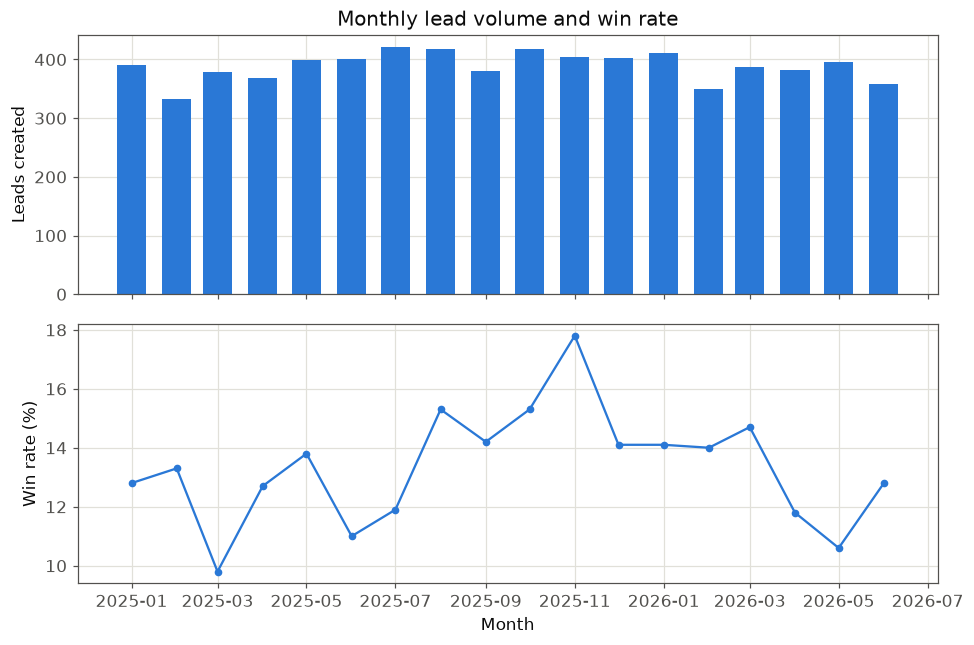

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.bar(monthly.index, monthly["leads"], color=BLUE, width=20)
ax1.set_ylabel("Leads created")
ax1.set_title("Monthly lead volume and win rate")

ax2.plot(monthly.index, monthly["win_rate_pct"], color=BLUE, marker="o", markersize=4)
ax2.set_ylabel("Win rate (%)")
ax2.set_xlabel("Month")

fig.tight_layout()
fig.savefig(ASSETS_DIR / "06_monthly_trend.png", dpi=150)
plt.show()


## Validate against Lesson 3's SQL results

Same purpose as the asserts at the end of the Lesson 2 cleaning notebook: if
the pandas numbers below don't match what the SQL queries produced, one of
the two pipelines has a bug and needs to be found before trusting either one.


In [16]:
assert funnel["Closed"] == 935, "Won count should match the SQL funnel query"
assert win_by_source.index[0] == "Referral" and round(win_by_source.iloc[0], 1) == 33.8
assert round(win_by_speed["1. Under 1 hour"], 1) == 22.8
assert round(lost_by_reason.loc["Price Objection", "total_lost_value"], 2) == 363258.99
assert rep_leaderboard.index[0] == "Rep_08" and round(rep_leaderboard.iloc[0]["total_revenue"], 2) == 103895.15

print("All KPI numbers match Lesson 3's SQL results.")
print("Charts saved to assets/:")
for p in sorted(ASSETS_DIR.glob("*.png")):
    print(" -", p.name)


All KPI numbers match Lesson 3's SQL results.
Charts saved to assets/:
 - 01_funnel_by_stage.png
 - 02_win_rate_by_source.png
 - 03_win_rate_by_response_time.png
 - 04_lost_value_by_reason.png
 - 05_rep_leaderboard.png
 - 06_monthly_trend.png


## What this says about the business

Referral and webinar leads convert far better than paid or cold-outreach
leads (33.8% and 26.1% vs. 6.6% and 0%), so the funnel-shape story isn't just
"more leads" - it's "more of the sources that already work." Speed-to-lead is
the single most actionable lever here: contacting a lead within the first
hour roughly doubles the win rate of the next bucket down, and it's something
a rep controls directly, unlike lead source. Price objection is the single
biggest reason deals are lost, worth more in unrealized pipeline value than
any other reason combined with room to spare. And the gap between the top rep
(Rep_08, 29.2% win rate) and the bottom of the leaderboard is wide enough that
it's worth asking what the top reps are doing differently - that's a natural
next question for the Streamlit dashboard and the README's findings section.

One caveat worth flagging rather than reading too much into: the last couple
of months in the trend chart dip lower, but that's partly an artifact of the
data's cutoff date (2026-06-29), not necessarily a real slowdown - a lead
created in mid-June hasn't had the weeks it normally takes to work through the
whole funnel and close yet, so recent months will always look under-converted
in this kind of snapshot. This is called right-censoring, and it's the reason
a real sales-ops report would usually exclude the most recent 4-6 weeks from
a win-rate trend, or footnote it.
